In [1]:
#from Ha: https://github.com/PanKbase/PanKbase-scRNA-seq/blob/main/1_preprocessing/2_barcode_qc.ipynb
#combining with Peter's python script in basal-qc.ipynb since this doesn't include ATAC right now

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import tables
import anndata
from typing import Dict, Optional
import numpy as np
import scipy.sparse as sp
from scipy import io
import glob
import os
import upsetplot
from scipy.io import mmread
import csv

In [2]:
#### FUNCTIONS FROM CELLBENDER
def dict_from_h5(file: str) -> Dict[str, np.ndarray]:
    """Read in everything from an h5 file and put into a dictionary."""
    d = {}
    with tables.open_file(file) as f:
        # read in everything
        for array in f.walk_nodes("/", "Array"):
            d[array.name] = array.read()
    return d


def anndata_from_h5(file: str,
                    analyzed_barcodes_only: bool = True) -> 'anndata.AnnData':
    """Load an output h5 file into an AnnData object for downstream work.
    Args:
        file: The h5 file
        analyzed_barcodes_only: False to load all barcodes, so that the size of
            the AnnData object will match the size of the input raw count matrix.
            True to load a limited set of barcodes: only those analyzed by the
            algorithm. This allows relevant latent variables to be loaded
            properly into adata.obs and adata.obsm, rather than adata.uns.
    Returns:
        adata: The anndata object, populated with inferred latent variables
            and metadata.
    """

    d = dict_from_h5(file)
    X = sp.csc_matrix((d.pop('data'), d.pop('indices'), d.pop('indptr')),
                      shape=d.pop('shape')).transpose().tocsr()

    # check and see if we have barcode index annotations, and if the file is filtered
    barcode_key = [k for k in d.keys() if (('barcode' in k) and ('ind' in k))]
    if len(barcode_key) > 0:
        max_barcode_ind = d[barcode_key[0]].max()
        filtered_file = (max_barcode_ind >= X.shape[0])
    else:
        filtered_file = True

    if analyzed_barcodes_only:
        if filtered_file:
            # filtered file being read, so we don't need to subset
            print('Assuming we are loading a "filtered" file that contains only cells.')
            pass
        elif 'barcode_indices_for_latents' in d.keys():
            X = X[d['barcode_indices_for_latents'], :]
            d['barcodes'] = d['barcodes'][d['barcode_indices_for_latents']]
        elif 'barcodes_analyzed_inds' in d.keys():
            X = X[d['barcodes_analyzed_inds'], :]
            d['barcodes'] = d['barcodes'][d['barcodes_analyzed_inds']]
        else:
            print('Warning: analyzed_barcodes_only=True, but the key '
                  '"barcodes_analyzed_inds" or "barcode_indices_for_latents" '
                  'is missing from the h5 file. '
                  'Will output all barcodes, and proceed as if '
                  'analyzed_barcodes_only=False')

    # Construct the anndata object.
    adata = anndata.AnnData(X=X,
                            obs={'barcode': d.pop('barcodes').astype(str)},
                            var={'gene_name': (d.pop('gene_names') if 'gene_names' in d.keys()
                                               else d.pop('name')).astype(str)},
                            dtype=X.dtype)
    adata.obs.set_index('barcode', inplace=True)
    adata.var.set_index('gene_name', inplace=True)

    # For CellRanger v2 legacy format, "gene_ids" was called "genes"... rename this
    if 'genes' in d.keys():
        d['id'] = d.pop('genes')

    # For purely aesthetic purposes, rename "id" to "gene_id"
    if 'id' in d.keys():
        d['gene_id'] = d.pop('id')

    # If genomes are empty, try to guess them based on gene_id
    if 'genome' in d.keys():
        if np.array([s.decode() == '' for s in d['genome']]).all():
            if '_' in d['gene_id'][0].decode():
                print('Genome field blank, so attempting to guess genomes based on gene_id prefixes')
                d['genome'] = np.array([s.decode().split('_')[0] for s in d['gene_id']], dtype=str)

    # Add other information to the anndata object in the appropriate slot.
    _fill_adata_slots_automatically(adata, d)

    # Add a special additional field to .var if it exists.
    if 'features_analyzed_inds' in adata.uns.keys():
        adata.var['cellbender_analyzed'] = [True if (i in adata.uns['features_analyzed_inds'])
                                            else False for i in range(adata.shape[1])]

    if analyzed_barcodes_only:
        for col in adata.obs.columns[adata.obs.columns.str.startswith('barcodes_analyzed')
                                     | adata.obs.columns.str.startswith('barcode_indices')]:
            try:
                del adata.obs[col]
            except Exception:
                pass
    else:
        # Add a special additional field to .obs if all barcodes are included.
        if 'barcodes_analyzed_inds' in adata.uns.keys():
            adata.obs['cellbender_analyzed'] = [True if (i in adata.uns['barcodes_analyzed_inds'])
                                                else False for i in range(adata.shape[0])]

    return adata


def _fill_adata_slots_automatically(adata, d):
    """Add other information to the adata object in the appropriate slot."""

    # TODO: what about "features_analyzed_inds"?  If not all features are analyzed, does this work?

    for key, value in d.items():
        try:
            if value is None:
                continue
            value = np.asarray(value)
            if len(value.shape) == 0:
                adata.uns[key] = value
            elif value.shape[0] == adata.shape[0]:
                if (len(value.shape) < 2) or (value.shape[1] < 2):
                    adata.obs[key] = value
                else:
                    adata.obsm[key] = value
            elif value.shape[0] == adata.shape[1]:
                if value.dtype.name.startswith('bytes'):
                    adata.var[key] = value.astype(str)
                else:
                    adata.var[key] = value
            else:
                adata.uns[key] = value
        except Exception:
            print('Unable to load data into AnnData: ', key, value, type(value))


#### END FUNCTIONS FROM CELLBENDER
            
def cellbender_anndata_to_cell_probability(a):
    return a.obs.cell_probability


def cellbender_anndata_to_sparse_matrix(adata, min_cell_probability=0):
    barcodes = adata.obs[adata.obs.cell_probability>=min_cell_probability].index.to_list()
    features = adata.var.gene_id.to_list()
    matrix = adata[adata.obs.cell_probability>=min_cell_probability].X.transpose()
    return {'features': features, 'barcodes': barcodes, 'matrix': matrix}


def umi_count_after_decontamination(adata):
    x = cellbender_anndata_to_sparse_matrix(adata)
    return dict(zip(x['barcodes'], x['matrix'].sum(axis=0).tolist()[0]))


def barcode_rank_plot(metrics, ax):
    df = metrics.sort_values('rna_umis', ascending=False)
    df['barcode_rank'] = range(1, len(df) + 1)
    sns.scatterplot(x='barcode_rank', y='rna_umis', data=df, ax=ax, hue='pass_all_filters', palette={True: 'red', False: 'black'}, edgecolor=None, alpha=0.2)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Barcode rank')
    ax.set_ylabel('UMIs')
    return ax


def rna_umis_vs_rna_mito_plot(metrics, ax):
    sns.scatterplot(x='rna_umis', y='rna_fraction_mitochondrial', data=metrics, ax=ax, hue='pass_all_filters', palette={True: 'red', False: 'black'}, edgecolor=None, alpha=0.02, s=3)
    ax.set_xscale('log')
    ax.set_xlabel('UMIs')
    ax.set_ylabel('Fraction mito. (RNA)')
    return ax

def cellbender_fraction_removed(metrics, ax):
    sns.scatterplot(x='rna_umis', y='fraction_cellbender_removed', data=metrics, ax=ax, hue='pass_all_filters', palette={True: 'red', False: 'black'}, edgecolor=None, alpha=0.05)
    ax.set_xscale('log')
    ax.set_xlabel('UMIs')
    ax.set_ylabel('Fraction ambient')
    return ax


def cellbender_cell_probabilities(metrics, ax):
    sns.histplot(x='cell_probability', data=metrics[(metrics.filter_rna_emptyDrops) & (metrics.filter_rna_max_mito)], ax=ax, bins=20)
    ax.set_xlabel('Cellbender cell prob.\nfor cells by EmptyDrops and mito. thresholds')
    return ax

### FUNCTION TO RUN MULTI-OTSU THRESHOLDING
from skimage.filters import threshold_multiotsu
def estimate_threshold(x, classes=3):
    # do on logscale
    values = np.log10(x).values
    values = values.reshape((len(values),1))
    thresholds = threshold_multiotsu(image=values, classes=classes, nbins=256)
    # convert back to linear scale
    thresholds = [pow(10, i) for i in thresholds]
    UMI_THRESHOLD = round(thresholds[classes - 2])
    return UMI_THRESHOLD

def rna_umis_vs_atac_hqaa_plot(metrics, ax):
    sns.scatterplot(x='rna_umis', y='atac_hqaa', data=metrics, ax=ax, hue='pass_all_filters', palette={True: 'red', False: 'black'}, edgecolor=None, alpha=0.02, s=3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('UMIs (RNA)')
    ax.set_ylabel('Pass filter reads (ATAC)')
    return ax


def atac_hqaa_vs_atac_tss_enrichment_plot(metrics, ax):
    sns.scatterplot(x='atac_hqaa', y='atac_tss_enrichment', data=metrics, ax=ax, hue='pass_all_filters', palette={True: 'red', False: 'black'}, edgecolor=None, alpha=0.02, s=3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Pass filter reads (ATAC)')
    ax.set_ylabel('TSS enrichment')
    return ax


In [3]:
dir = "/scratch/scjp_root/scjp1/christav/fap_village_multiome/results/RNA_results" #change dir to where QC data is stored
donor = "basal" #change to which donor's data is being processed

#with open('/nfs/turbo/umms-scjp-pank/1_HPAP/metadata/PancDB_scRNA-seq_metadata_10x.txt', 'r') as file: #obtain metadata
#    reader = csv.reader(file, delimiter='\t')
#    for row in reader:
#        if row[0] == donor:
#            metadata = row
            
CELLBENDER = dir + '/cellbender/' + donor + '-hg38.cellbender_FPR_0.05.h5'
RNA_METRICS = dir + '/qc/' + donor + '-hg38.qc.txt'
PASS_QC = dir + "/emptyDrops/" + donor + "-hg38.pass.txt"
KNEE_FILE  = dir + "/emptyDrops/" + donor + "-hg38.knee.txt"

RNA_BARCODE_WHITELIST = "/scratch/scjp_root/scjp1/christav/fap_village_multiome/Github/snRNAseq-NextFlow/737-arc-v1.txt"

GENE_FULL_EXON_OVER_INTRON_COUNTS = dir + '/starsolo/' + donor + '-hg38/' + donor + '-hg38.Solo.out/GeneFull_ExonOverIntron/raw'
GENE_COUNTS = dir + '/starsolo/' + donor + '-hg38/' + donor + '-hg38.Solo.out/Gene/raw/'

ATAC_METRICS = "/scratch/scjp_root/scjp1/christav/fap_village_multiome/results/ATAC_results/ataqv/single-nucleus/basal-hg38.txt"

THRESHOLD_ATAC_MIN_HQAA = 3000
THRESHOLD_ATAC_MIN_TSS_ENRICHMENT = 2
THRESHOLD_RNA_MIN_UMI = 499

#convert RNA to ATAC
ATAC_BARCODE_WHITELIST = "/scratch/scjp_root/scjp1/christav/fap_village_multiome/Github/snATACseq-NextFlow/737K-arc-v1.txt"

rna_barcodes = pd.read_csv(RNA_BARCODE_WHITELIST, header=None)[0].to_list()
atac_barcodes = pd.read_csv(ATAC_BARCODE_WHITELIST, header=None)[0].to_list()
atac_to_rna = dict(zip(atac_barcodes, rna_barcodes))

In [4]:
rna_barcodes = pd.read_csv(RNA_BARCODE_WHITELIST, header=None)[0].to_list()
adata = anndata_from_h5(CELLBENDER, analyzed_barcodes_only=True)
rna_metrics = pd.read_csv(RNA_METRICS, sep='\t')
rna_metrics = rna_metrics[rna_metrics.barcode!='-']

atac_metrics = pd.read_csv(ATAC_METRICS, sep='\t', index_col=0).rename_axis(index='barcode')
KEEP_ATAC_METRICS = ['median_fragment_length', 'hqaa', 'max_fraction_reads_from_single_autosome', 'percent_mitochondrial', 'tss_enrichment']
atac_metrics = atac_metrics[KEEP_ATAC_METRICS]
atac_metrics.max_fraction_reads_from_single_autosome = atac_metrics.max_fraction_reads_from_single_autosome.fillna(0)
atac_metrics.median_fragment_length = atac_metrics.median_fragment_length.fillna(0)
atac_metrics.percent_mitochondrial = atac_metrics.percent_mitochondrial.fillna(0)
atac_metrics.tss_enrichment = atac_metrics.tss_enrichment.fillna(0)
atac_metrics['fraction_mitochondrial'] = atac_metrics.percent_mitochondrial / 100

atac_metrics.index = atac_metrics.index.map(atac_to_rna)
metrics = rna_metrics.set_index('barcode').rename(columns=lambda x: 'rna_' + x).join(atac_metrics.rename(columns=lambda x: 'atac_' + x))

metrics = metrics.reset_index()
cell_probability = cellbender_anndata_to_cell_probability(adata)
post_cellbender_umis = umi_count_after_decontamination(adata)

metrics['cell_probability'] = metrics.barcode.map(lambda x: cell_probability[x] if x in cell_probability else np.nan)
metrics['post_cellbender_umis'] = metrics.barcode.map(lambda x: post_cellbender_umis[x] if x in post_cellbender_umis else np.nan)
metrics['fraction_cellbender_removed'] = (metrics.rna_umis - metrics.post_cellbender_umis) / metrics.rna_umis
metrics['mt_pct'] = metrics.rna_fraction_mitochondrial * 100
metrics['pct_cellbender_removed'] = metrics.fraction_cellbender_removed * 100
metrics.head()

/home/christav/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


,barcode,rna_total_reads,rna_uniquely_mapped_reads,rna_secondary_alignments,rna_supplementary_alignments,rna_umis,rna_fraction_mitochondrial,atac_median_fragment_length,atac_hqaa,atac_max_fraction_reads_from_single_autosome,atac_percent_mitochondrial,atac_tss_enrichment,atac_fraction_mitochondrial,cell_probability,post_cellbender_umis,fraction_cellbender_removed,mt_pct,pct_cellbender_removed
0,CTGTTGGAGTGGACAA,114342,102582,11987,0,19387.0,0.040358,171.0,7069.0,0.082473,8.475022,3.982213,0.084750,0.999955,18968.0,0.021612,4.035796,2.161242
1,ACAGCCGGTCATGCCC,104259,92047,26809,0,16486.0,0.069562,170.0,65081.0,0.101812,7.708806,4.728056,0.077088,0.999955,15901.0,0.035485,6.956229,3.548465
2,TAGGCTTAGTTAGGCT,76313,69108,7267,0,12278.0,0.128263,178.0,80708.0,0.085593,9.016943,4.086531,0.090169,0.999955,11821.0,0.037221,12.826301,3.722105
3,TCGGTAAGTATTGAGT,46165,41265,5664,0,7255.0,0.082346,161.0,93279.0,0.073243,2.843600,4.394942,0.028436,0.999884,6381.0,0.120469,8.234581,12.046864
4,ATATGTCCACTTCATC,223230,200157,29755,0,36005.0,0.068621,172.0,16361.0,0.091070,22.032916,4.842296,0.220329,0.999955,35818.0,0.005194,6.862113,0.519372


In [5]:
bc = pd.read_csv(PASS_QC, header=0, delim_whitespace="\t") 
metrics['filter_rna_emptyDrops'] = metrics['barcode'].isin(bc.barcode)

In [6]:
THRESHOLD_CELLBENDER_MIN_CELL_PROBABILITY = 0.99 #probability threshold for a barcode truly corresponding to a cell
metrics['filter_cellbender_cell_probability'] = metrics.cell_probability >= THRESHOLD_CELLBENDER_MIN_CELL_PROBABILITY

In [7]:
with open(KNEE_FILE, 'r') as file:
    reader = csv.reader(file, delimiter='\t')
    next(reader, None)
    for row in reader:
        knee = round(float(row[0]))
        inflection = round(float(row[1]))
        inflection_rank = round(float(row[2]))
        knee_rank = round(float(row[3]))
        endCliff = round(float(row[4]))
        end_cliff_rank = round(float(row[5]))
        plateau = round(float(row[6]))

In [8]:
### get THRESHOLD_RNA_MAX_MITO
THRESHOLD_RNA_MAX_MITO = estimate_threshold(metrics[((metrics.rna_umis < endCliff) |
                                                    (metrics.filter_rna_emptyDrops == True)) &
                                                    (metrics.mt_pct>0) & (metrics.mt_pct<30)].mt_pct.astype(float),
                                           classes = 3)
metrics['filter_rna_max_mito'] = metrics.rna_fraction_mitochondrial <= THRESHOLD_RNA_MAX_MITO/100
THRESHOLD_RNA_MAX_MITO

15

In [9]:
THRESHOLD_FRACTION_CB_REMOVED = estimate_threshold(metrics[(metrics.filter_rna_emptyDrops == True) &
                                                         (metrics.pct_cellbender_removed>0) &
                                                         (np.isnan(metrics.pct_cellbender_removed) == False)].pct_cellbender_removed.astype(float),
                                                  classes = 4)
metrics['filter_pct_cellbender_removed'] = metrics.pct_cellbender_removed <= THRESHOLD_FRACTION_CB_REMOVED
#THRESHOLD_POST_CELLBENDER_UMIS = 100
#metrics['filter_rna_postcellbender_min_umi'] = metrics.post_cellbender_umis >= THRESHOLD_POST_CELLBENDER_UMIS

In [10]:
metrics['filter_atac_min_hqaa'] = metrics.atac_hqaa >= THRESHOLD_ATAC_MIN_HQAA
metrics['filter_atac_min_tss_enrichment'] = metrics.atac_tss_enrichment >= THRESHOLD_ATAC_MIN_TSS_ENRICHMENT

# apply QC thresholds
metrics['pass_all_filters'] = metrics.filter(like='filter_').all(axis=1)

# List of pass-QC barcodes
pass_qc_cells = list(sorted(metrics[metrics.pass_all_filters].barcode.to_list()))

/tmp/ipykernel_4174714/3052843413.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/sw/pkgs/arc/python3.11-anaconda/2024.02-1/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


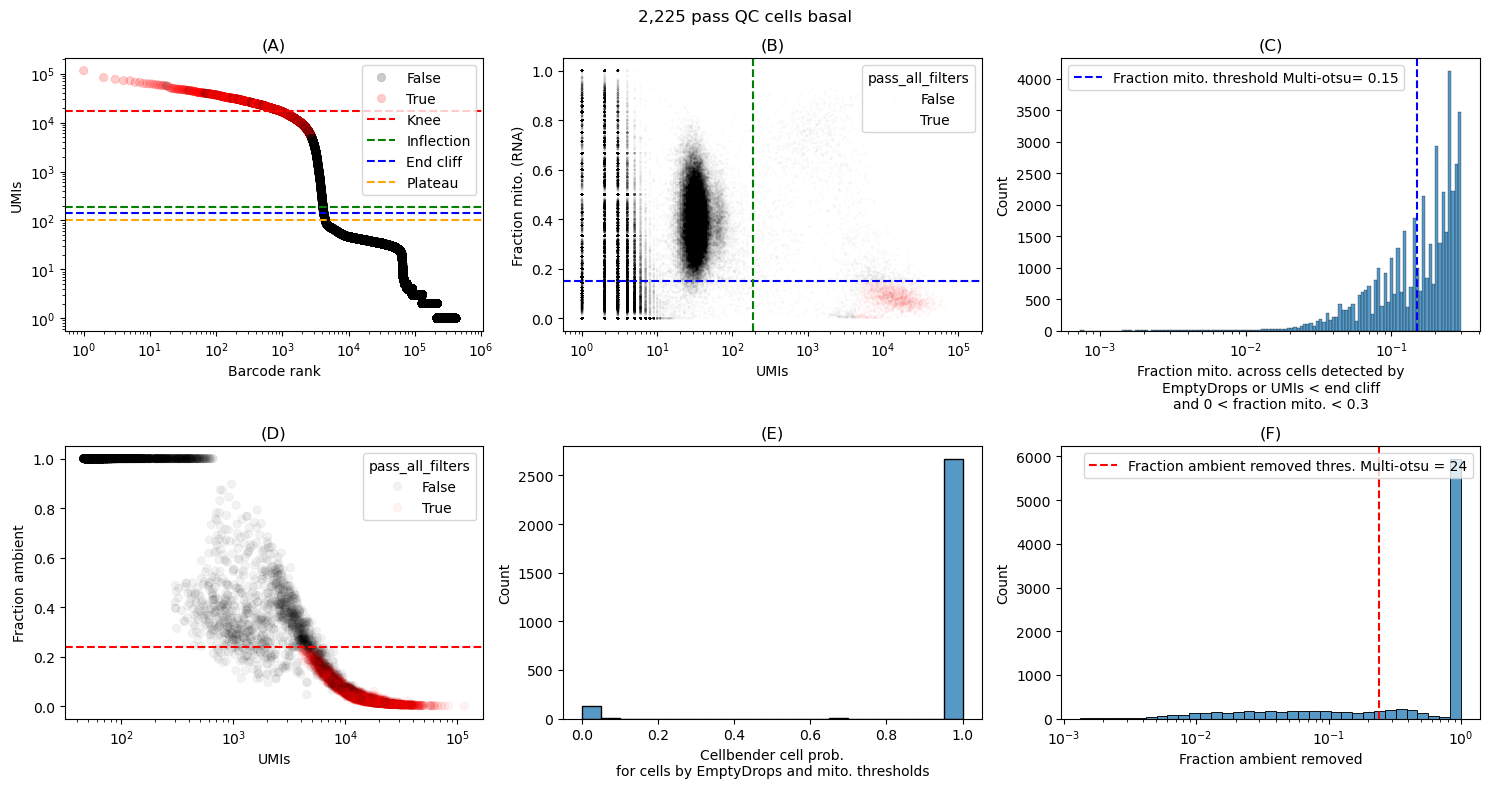

/tmp/ipykernel_4174714/3052843413.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig("basal-qc-2.png", bbox_inches='tight', dpi=300)


In [11]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(5*3, 8))

ax = axs[0, 0]
barcode_rank_plot(metrics, ax)
ax.axhline(knee, color='red', ls='--', label='Knee')
ax.axhline(inflection, color='green', ls='--', label='Inflection')
ax.axhline(endCliff, color='blue', ls='--', label='End cliff')
ax.axhline(plateau, color='orange', ls='--', label='Plateau')
ax.legend()
ax.set_title('(A)')

ax = axs[0, 1]
rna_umis_vs_rna_mito_plot(metrics, ax)
ax.axhline(THRESHOLD_RNA_MAX_MITO/100, color='blue', ls='--')
ax.axvline(inflection, color='green', ls='--')
ax.set_title('(B)')

ax = axs[0, 2] #this plot is subjected to changes when optimizing for %MT thresholds
sns.histplot(x='rna_fraction_mitochondrial', data=metrics[((metrics.rna_umis < endCliff) | (metrics.filter_rna_emptyDrops == True)) & (metrics.mt_pct>0) & (metrics.mt_pct<30)], ax=ax, log_scale=True)
ax.axvline(THRESHOLD_RNA_MAX_MITO/100, color='blue', ls='--', label='Fraction mito. threshold Multi-otsu= {:,}'.format(THRESHOLD_RNA_MAX_MITO/100))
ax.legend()
ax.set_xlabel('Fraction mito. across cells detected by\nEmptyDrops or UMIs < end cliff\nand 0 < fraction mito. < 0.3')
ax.set_title('(C)')

ax = axs[1, 0]
cellbender_fraction_removed(metrics, ax)
ax.axhline(THRESHOLD_FRACTION_CB_REMOVED/100, color='red', ls='--')
ax.set_title('(D)')

ax = axs[1, 1]
cellbender_cell_probabilities(metrics, ax)
ax.set_title('(E)')

ax = axs[1, 2]
sns.histplot(x='fraction_cellbender_removed', data=metrics[(metrics.barcode!='-')], ax=ax, log_scale=True)
ax.axvline(THRESHOLD_FRACTION_CB_REMOVED/100, color='red', ls='--', label='Fraction ambient removed thres. Multi-otsu = {:,}'.format(THRESHOLD_FRACTION_CB_REMOVED))
ax.legend()
ax.set_xlabel('Fraction ambient removed')
ax.set_title('(F)')

fig.suptitle('{:,} pass QC cells'.format(len(pass_qc_cells)) + " " + donor)

plt.tight_layout()
plt.show()

fig.savefig("basal-qc-2.png", bbox_inches='tight', dpi=300)

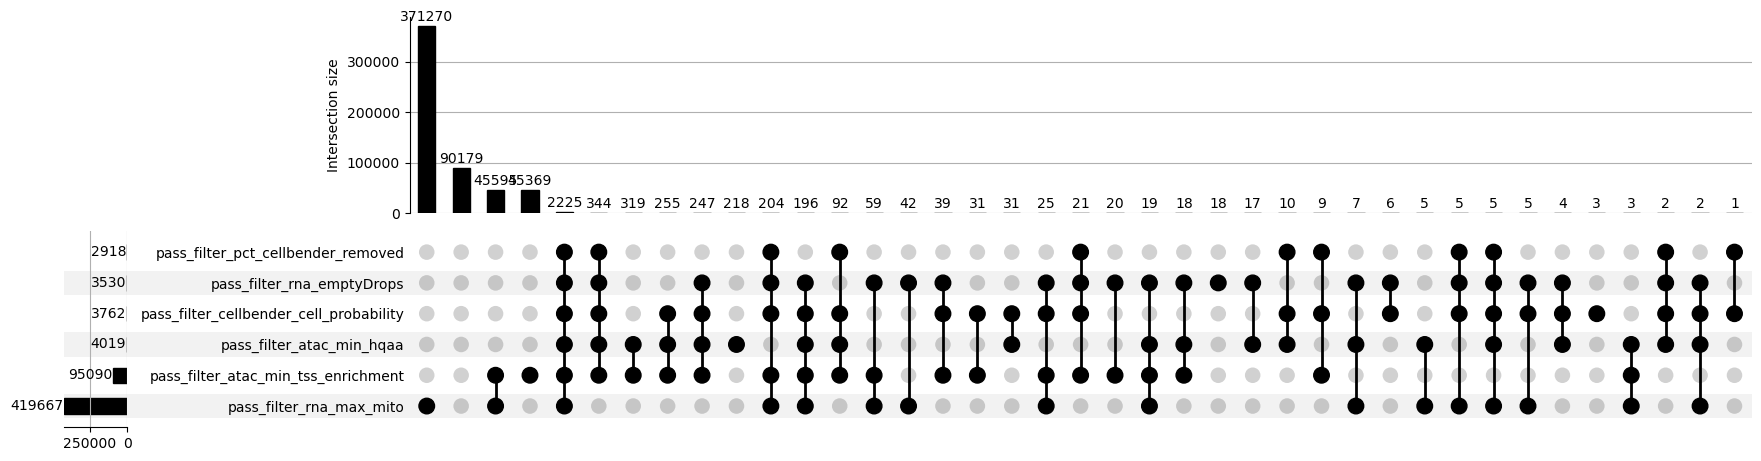

In [12]:
# Plot the number of nuclei passing each filter
fig, ax = plt.subplots(figsize=(7, 6))
ax.remove()

for_upset = metrics.filter(like='filter_').rename(columns=lambda x: 'pass_' + x)
for_upset = for_upset.groupby(for_upset.columns.to_list()).size()
upsetplot.plot(for_upset, fig=fig, sort_by='cardinality', show_counts=True)
fig.savefig('basal-qc-upset-2.png', dpi=300, facecolor='white', bbox_inches='tight')

/tmp/ipykernel_4174714/2022378373.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_4174714/2022378373.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig('basal-qc-atac-2.png', dpi=300, facecolor='white', bbox_inches='tight')
/sw/pkgs/arc/python3.11-anaconda/2024.02-1/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/sw/pkgs/arc/python3.11-anaconda/2024.02-1/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


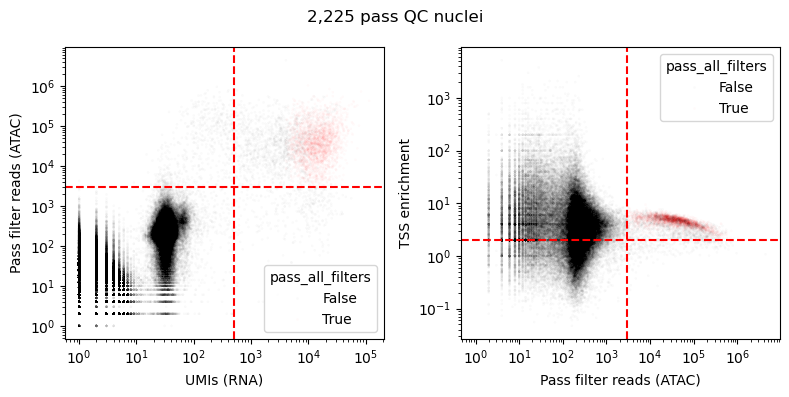

In [17]:
#atac plots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(2*4, 4))

ax = axs[0]
rna_umis_vs_atac_hqaa_plot(metrics, ax)
ax.axhline(THRESHOLD_ATAC_MIN_HQAA, color='red', ls='--')
ax.axvline(THRESHOLD_RNA_MIN_UMI, color='red', ls='--')

ax = axs[1]
atac_hqaa_vs_atac_tss_enrichment_plot(metrics, ax)
ax.axvline(THRESHOLD_ATAC_MIN_HQAA, color='red', ls='--')
ax.axhline(THRESHOLD_ATAC_MIN_TSS_ENRICHMENT, color='red', ls='--')

fig.suptitle('{:,} pass QC nuclei'.format(len(pass_qc_cells)))
fig.tight_layout()
fig.savefig('basal-qc-atac-2.png', dpi=300, facecolor='white', bbox_inches='tight')

In [18]:
with open('basal-hg38-2.pass-qc.rna.txt', 'w') as fh:
    fh.write('\n'.join(pass_qc_cells) + '\n')

In [19]:
#save atac barcodes

rna_to_atac = {v: k for k, v in atac_to_rna.items()}
pass_qc_atac = [rna_to_atac[barcode] for barcode in pass_qc_cells if barcode in rna_to_atac]
pass_qc_atac = list(sorted(pass_qc_atac))

with open('basal-hg38-2.pass-qc.atac.txt', 'w') as fh:
    fh.write('\n'.join(pass_qc_atac) + '\n')